# Credit Card Fraud Detection

## Project Overview

This project builds machine learning models to detect fraudulent credit card transactions using the Kaggle Credit Card Fraud Detection dataset.

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions. Therefore, model evaluation focuses on metrics that are more meaningful for fraud detection:

- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

To address class imbalance, **SMOTE (Synthetic Minority Oversampling Technique)** is applied to the training data.

Two machine learning models are trained and compared:

1. Random Forest
2. XGBoost

The primary objective is to detect as many fraudulent transactions as possible while maintaining reasonable precision.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib
from pathlib import Path
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load Dataset

In [5]:
data_path = "../data/creditcard.csv"
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")

Dataset shape: (284807, 31)


In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 2. Exploratory Data Analysis

In [8]:
# Missing values
missing_values = df.isnull().sum().sum()
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total missing values: {missing_values:,}")
print(f"Duplicate rows: {duplicate_rows:,}")

Total missing values: 0
Duplicate rows: 1,081


In [18]:
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Duplicate rows including their original occurrences: {len(duplicate_rows):,}")
duplicate_rows["Class"].value_counts()

Duplicate rows including their original occurrences: 1,854


Class
0    1822
1      32
Name: count, dtype: int64

In [19]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Fraud among duplicated rows: {duplicate_rows['Class'].sum():,}")

Duplicate rows: 1,081
Fraud among duplicated rows: 32


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Class Distribution

Fraud detection is a highly imbalanced classification problem. Most transactions are legitimate, while fraudulent transactions form only a very small minority.

Understanding this imbalance is important because accuracy can be misleading in such a scenario.

In [10]:
class_counts = df["Class"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(df) * 100)
})
class_distribution

,Class,Count,Percentage
0,Legitimate,284315,99.827251
1,Fraud,492,0.172749


In [11]:
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Legitimate transactions: {class_counts[0]:,}")
print(f"Fraudulent transactions: {class_counts[1]:,}")
print(f"Imbalance ratio: approximately {imbalance_ratio:.0f}:1")

Legitimate transactions: 284,315
Fraudulent transactions: 492
Imbalance ratio: approximately 578:1


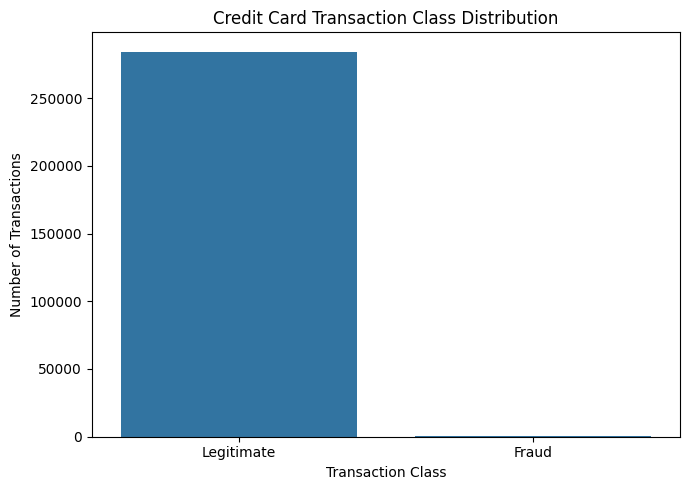

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="Class"
)
plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

plt.savefig(
    "../outputs/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Transaction Amount

Transaction amount may differ between legitimate and fraudulent transactions. Because transaction amounts are highly skewed, the median and distribution are more informative than relying only on the mean.

In [13]:
amount_summary = (
    df.groupby("Class")["Amount"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={0: "Legitimate", 1: "Fraud"})
)

amount_summary

,count,mean,median,std,min,max
Class,,,,,,
Legitimate,284315,88.291022,22.00,250.105092,0.0,25691.16
Fraud,492,122.211321,9.25,256.683288,0.0,2125.87


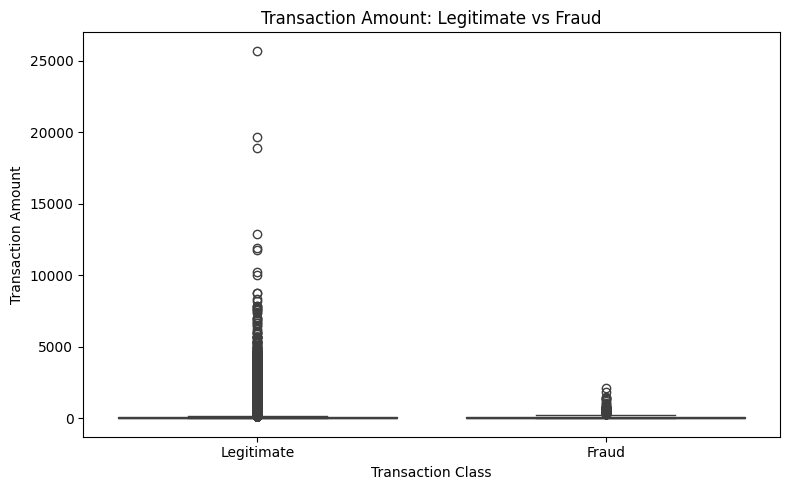

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount: Legitimate vs Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

plt.savefig(
    "../outputs/amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Transaction Time

The `Time` feature represents the elapsed time since the first transaction in the dataset. We examine whether fraudulent transactions appear to follow a different temporal pattern from legitimate transactions.

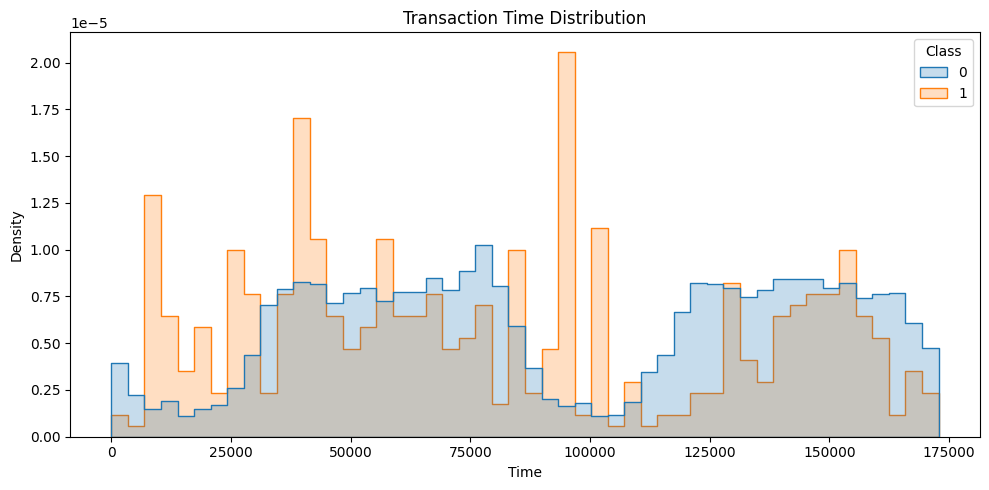

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    "../outputs/time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Data Cleaning

The dataset contains exact duplicate transaction records. Since duplicates can cause the same transaction to appear in both the training and testing sets, they are removed before model development to reduce the risk of data leakage.

After removing duplicates, the cleaned dataset is used for the remaining preprocessing and modeling steps.

In [20]:
# Remove exact duplicate records
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (283726, 31)


In [21]:
class_counts = df["Class"].value_counts().sort_index()
print(f"Legitimate transactions: {class_counts[0]:,}")
print(f"Fraudulent transactions: {class_counts[1]:,}")
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"Fraud percentage: {fraud_percentage:.4f}%")

Legitimate transactions: 283,253
Fraudulent transactions: 473
Fraud percentage: 0.1667%


## 5. Data Preprocessing

The target variable is `Class`, where 0 represents legitimate transactions and 1 represents fraudulent transactions.

The data is divided into training and testing sets using stratified sampling to preserve the original fraud ratio in both sets.

Since the anonymized `V1`–`V28` features are already PCA-transformed, only the `Amount` feature is standardized. The scaler is fitted on the training data and then applied to the test data to prevent data leakage.

In [22]:
X = df.drop(columns="Class")
y = df["Class"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (226980, 30)
Testing set: (56746, 30)


In [24]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [25]:
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
# Apply the same scaler to test data
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

In [26]:
print("Training Amount:")
print(X_train["Amount"].describe())
print("\nTesting Amount:")
print(X_test["Amount"].describe())

Training Amount:
count    2.269800e+05
mean     7.487965e-17
std      1.000002e+00
min     -3.596386e-01
25%     -3.364866e-01
50%     -2.697972e-01
75%     -4.287453e-02
max      7.962087e+01
Name: Amount, dtype: float64

Testing Amount:
count    56746.000000
mean         0.001741
std          1.091001
min         -0.359639
25%         -0.337300
50%         -0.271811
75%         -0.048378
max        104.175192
Name: Amount, dtype: float64


## 6. Handling Class Imbalance with SMOTE

The cleaned dataset remains highly imbalanced, with fraudulent transactions representing only a small fraction of all transactions.

SMOTE (Synthetic Minority Oversampling Technique) is applied to the **training set only**. It generates synthetic examples of the minority class to create a balanced training dataset.

The test set is kept untouched so that model performance is evaluated on the original class distribution.

In [27]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [28]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample( X_train, y_train)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


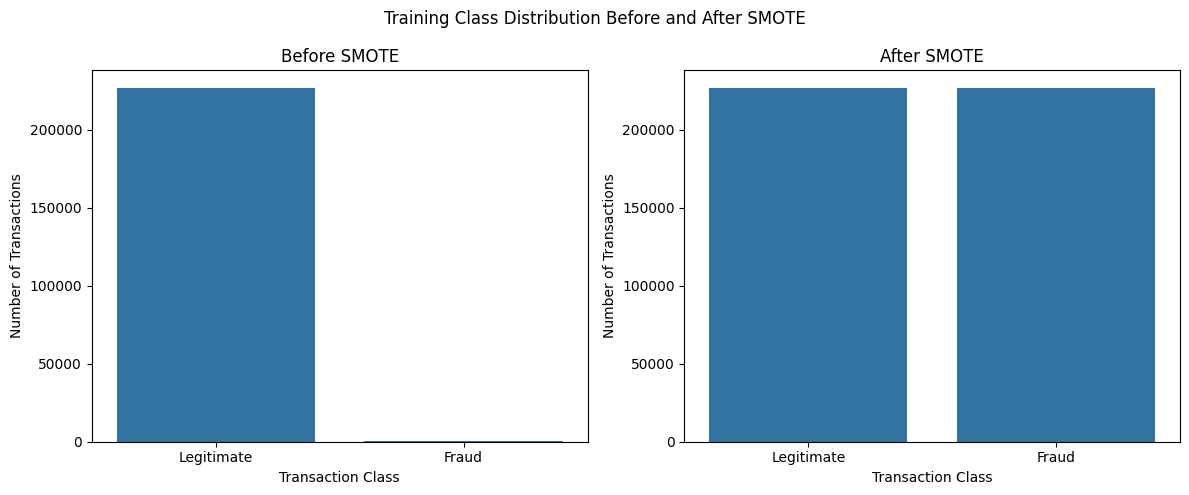

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Transaction Class")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legitimate", "Fraud"])

# After SMOTE
sns.countplot(
    x=y_train_smote,
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Transaction Class")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Legitimate", "Fraud"])

plt.suptitle("Training Class Distribution Before and After SMOTE")

plt.tight_layout()

plt.savefig(
    "../outputs/smote_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and robustness.

The model is trained using the SMOTE-balanced training data and evaluated on the original, untouched test set.

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest training completed.")

Random Forest training completed.


In [31]:
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


## 8. XGBoost

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each new tree focusing on improving the errors made by previous trees.

The model uses the same SMOTE-balanced training data and the same untouched test set used for Random Forest, allowing a fair comparison between the two models.

In [32]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost training completed.")

XGBoost training completed.


In [33]:
xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


## 9. Model Evaluation

Because the dataset is highly imbalanced, accuracy is not used as an evaluation metric.

The models are compared using:

- **Precision** — proportion of predicted fraud transactions that are actually fraudulent.
- **Recall** — proportion of actual fraud transactions correctly detected.
- **F1-Score** — harmonic mean of precision and recall.
- **ROC-AUC** — ability of the model to distinguish fraudulent from legitimate transactions.

Recall is particularly important because a false negative represents a fraudulent transaction that was missed.

In [38]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    return {
        "Model": model_name,
        "Accuracy":accuracy_score(y_true,predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1-Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

In [39]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions,
    xgb_probabilities
)

In [40]:
results_df = pd.DataFrame([
    rf_results,
    xgb_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.999471,0.901235,0.768421,0.829545,0.962651
1,XGBoost,0.999330,0.800000,0.800000,0.800000,0.962268


In [43]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)
print("Model comparison saved.")

Model comparison saved.


## 10. Confusion Matrix

The confusion matrix provides a detailed view of the classification results.

For fraud detection, **False Negatives (FN)** are particularly important because they represent fraudulent transactions that the model failed to detect.

In [41]:
rf_cm = confusion_matrix(y_test, rf_predictions)
xgb_cm = confusion_matrix(y_test, xgb_predictions)

print("Random Forest Confusion Matrix:")
print(rf_cm)

print("\nXGBoost Confusion Matrix:")
print(xgb_cm)

Random Forest Confusion Matrix:
[[56643     8]
 [   22    73]]

XGBoost Confusion Matrix:
[[56632    19]
 [   19    76]]


In [42]:
rf_fn = rf_cm[1, 0]
xgb_fn = xgb_cm[1, 0]

print(f"Random Forest missed frauds (False Negatives): {rf_fn}")
print(f"XGBoost missed frauds (False Negatives): {xgb_fn}")

Random Forest missed frauds (False Negatives): 22
XGBoost missed frauds (False Negatives): 19


### Fraud Detection Analysis

The confusion matrices highlight the trade-off between detecting fraudulent transactions and generating false fraud alerts.

Random Forest produced 22 false negatives, meaning 22 fraudulent transactions were missed. It produced only 8 false positives.

XGBoost reduced the number of missed fraudulent transactions to 19 and correctly identified 76 fraudulent transactions. However, it produced 19 false positives.

Therefore, XGBoost provides better fraud detection coverage, while Random Forest provides higher precision and fewer false alerts.

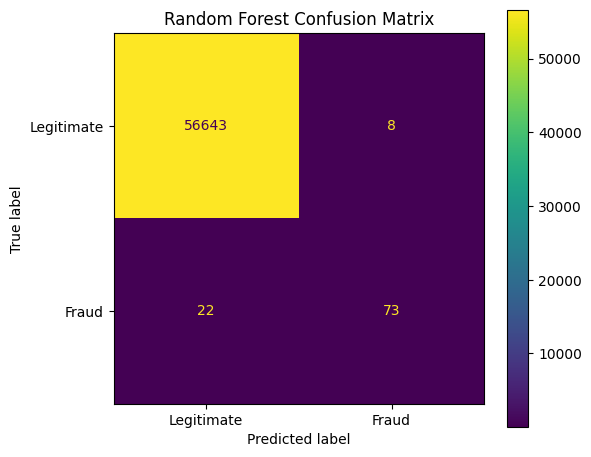

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Legitimate", "Fraud"]
).plot(ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "../outputs/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

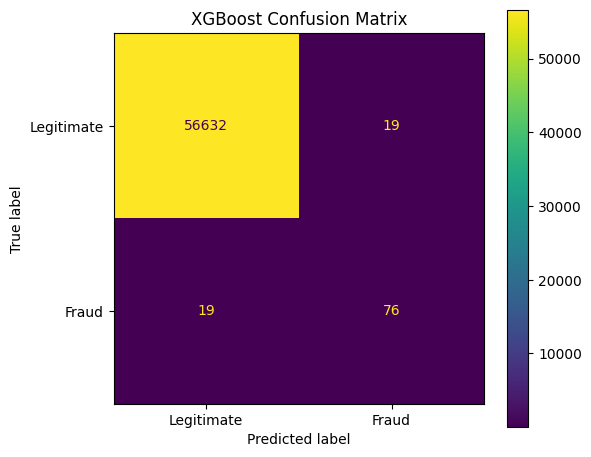

In [45]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Legitimate", "Fraud"]
).plot(ax=ax)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Sample Prediction Comparison

To demonstrate how the trained models behave on individual unseen transactions, a random sample of transactions is selected from the original test set.

The Random Forest and XGBoost predictions are compared with the actual transaction class.

This is only for qualitative inspection; the overall model performance is based on the complete test set and the evaluation metrics above.

In [49]:
fraud_test = X_test[y_test == 1]

fraud_indices = fraud_test.sample(
    n=min(10, len(fraud_test)),
    random_state=RANDOM_STATE
).index

fraud_sample_X = X_test.loc[fraud_indices]
fraud_sample_y = y_test.loc[fraud_indices]

fraud_sample_comparison = pd.DataFrame({
    "Actual": fraud_sample_y,
    "Random Forest": rf_model.predict(fraud_sample_X),
    "XGBoost": xgb_model.predict(fraud_sample_X)
})

fraud_sample_comparison.replace(label_map)

,Actual,Random Forest,XGBoost
56464,Fraud,Legitimate,Legitimate
228865,Fraud,Fraud,Fraud
162967,Fraud,Fraud,Fraud
93461,Fraud,Fraud,Fraud
115676,Fraud,Fraud,Fraud
177539,Fraud,Fraud,Fraud
63374,Fraud,Fraud,Fraud
247381,Fraud,Fraud,Fraud
15423,Fraud,Fraud,Fraud
72475,Fraud,Legitimate,Legitimate


### MODEL COMPARISON

In [50]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.999471,0.901235,0.768421,0.829545,0.962651
1,XGBoost,0.999330,0.800000,0.800000,0.800000,0.962268


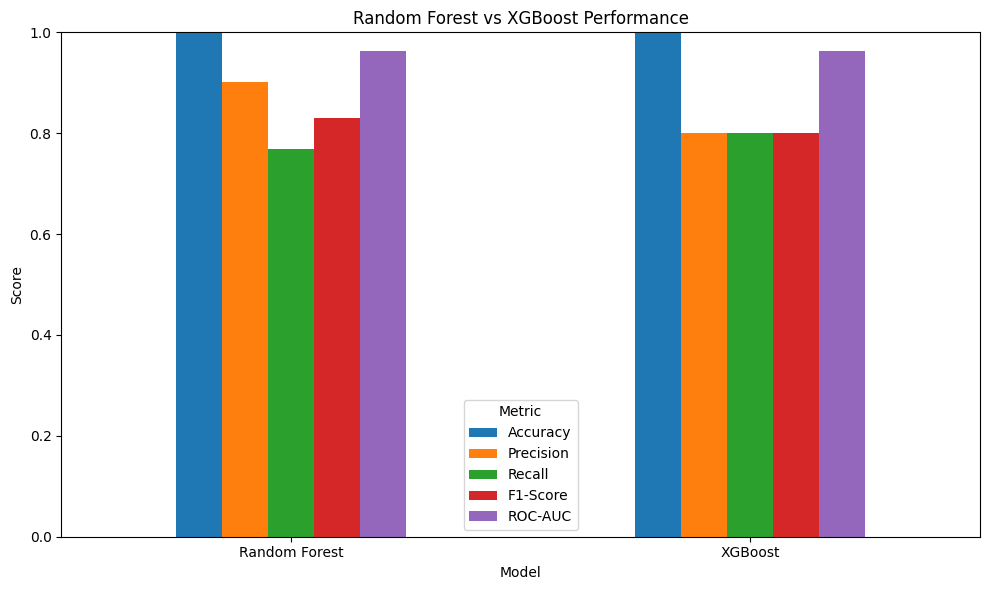

In [52]:
comparison_plot = results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Random Forest vs XGBoost Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()

plt.savefig(
    "../outputs/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
best_recall_model = results_df.loc[
    results_df["Recall"].idxmax(),
    "Model"
]

best_f1_model = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

best_roc_auc_model = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

print(f"Best Recall: {best_recall_model}")
print(f"Best F1-Score: {best_f1_model}")
print(f"Best ROC-AUC: {best_roc_auc_model}")

Best Recall: XGBoost
Best F1-Score: Random Forest
Best ROC-AUC: Random Forest


## 12. Feature Importance

Feature importance shows which input features contributed most to the Random Forest's decisions.

The `V1`–`V28` variables are anonymized PCA components, so their importance can be assessed quantitatively but cannot be directly interpreted as specific real-world transaction attributes.

In [54]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(10)

V14    0.211686
V10    0.126755
V4     0.115226
V12    0.111730
V17    0.095511
V3     0.073919
V16    0.050757
V11    0.049298
V2     0.030284
V9     0.019205
dtype: float64

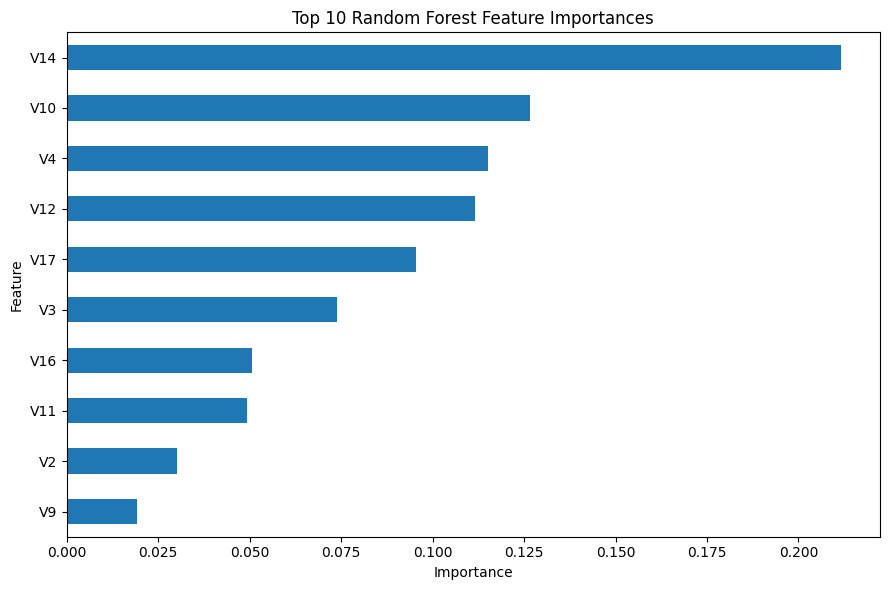

In [55]:
plt.figure(figsize=(9, 6))
rf_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../outputs/rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Save Models

The trained Random Forest and XGBoost models, along with the fitted `Amount` scaler, are saved for future use without retraining.

In [56]:
joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

joblib.dump(
    scaler,
    "../models/amount_scaler.pkl"
)

print("Models and scaler saved successfully.")

Models and scaler saved successfully.
